# Chapter 2: The Mathematics of Belief
We compute normalized Bayesian updating, regression toward the mean and a
survivorship mechanism with fully synthetic data. No historical microdata are implied.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.stats import beta
rng=begin(2)

## Seven successes in ten observations
With Beta(a,b) prior, the posterior is Beta(a+successes,b+failures).

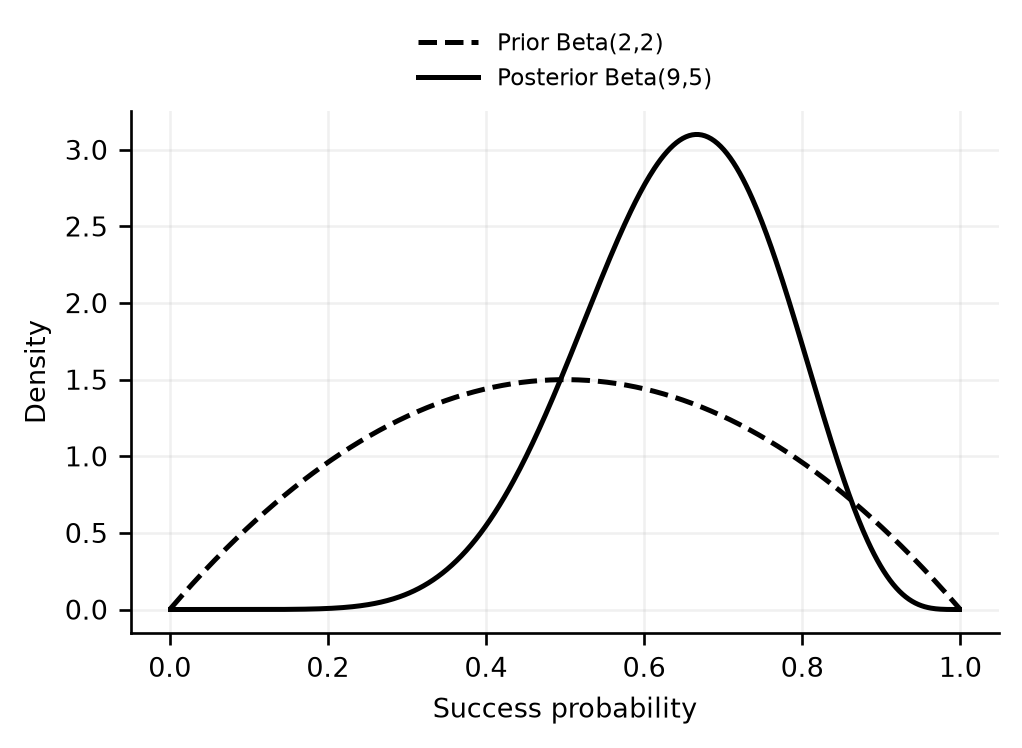

In [2]:
x=np.linspace(.001,.999,500); prior=(2,2); posterior=(9,5)
plt.figure(); plt.plot(x,beta.pdf(x,*prior),color='black',ls='--',label='Prior Beta(2,2)'); plt.plot(x,beta.pdf(x,*posterior),color='black',ls='-',label='Posterior Beta(9,5)'); plt.xlabel('Success probability'); plt.ylabel('Density'); plt.legend()
save(2,1,'Beliefs change in proportion to evidence','A synthetic ten-trial sample with seven successes updates a Beta(2,2) prior. Both curves are normalized probability densities.','## Part One: The Essay in the Drawer')

## Repeated measurements contain persistent signal and fresh noise
The conditional expectation slopes less than one on comparable standardized
scales. This is not a force that changes the population distribution.

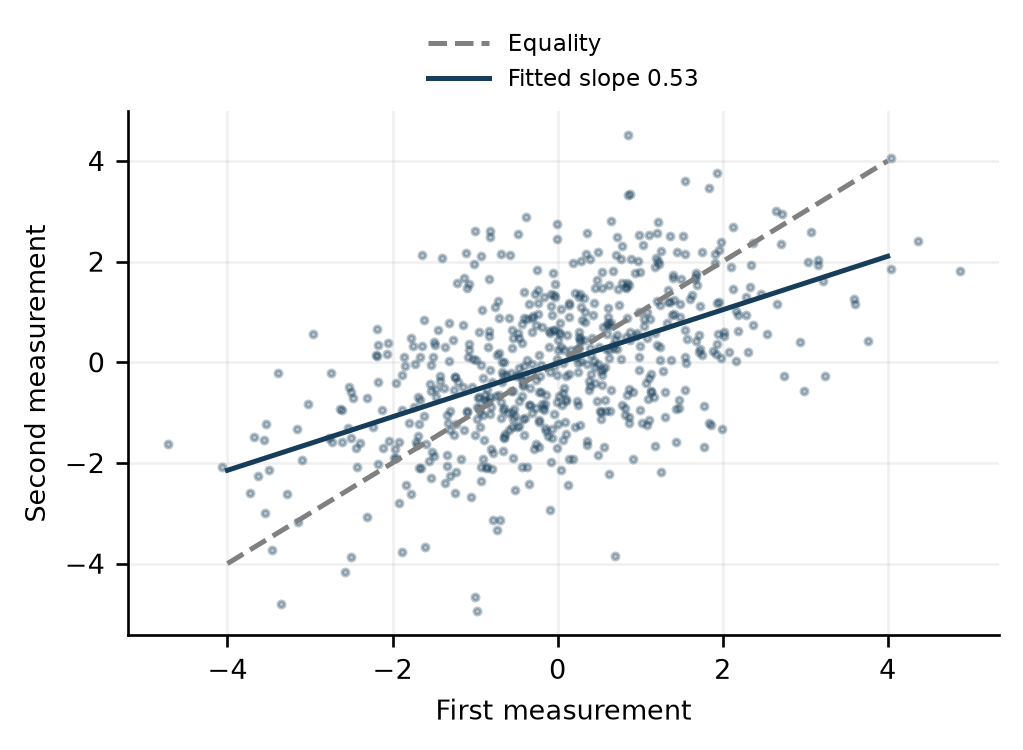

In [3]:
ability=rng.normal(size=600); first=ability+rng.normal(size=600); second=ability+rng.normal(size=600)
slope,intercept=np.polyfit(first,second,1)
plt.figure(); plt.scatter(first,second,s=4,alpha=.3); grid=np.array([-4,4]); plt.plot(grid,grid,ls='--',color='.5',label='Equality'); plt.plot(grid,intercept+slope*grid,label=f'Fitted slope {slope:.2f}'); plt.xlabel('First measurement'); plt.ylabel('Second measurement'); plt.legend()
save(2,2,'Extremes contain temporary noise','Synthetic measurements share an underlying ability but have independent noise. Extreme first measurements predict less extreme second measurements.','## Part Three: Taller Parents, Less Tall Children')

## The observation process selects the survivors
The aircraft diagram is an AI-generated conceptual illustration, not a wartime
damage map or an output of the simulation below. Dots show hypothetical damage
on returning aircraft only. Missing aircraft are not represented. Inferring
vulnerability also requires assumptions about exposure and survival; blank areas
alone are not proof. The following simulation makes the selection mechanism explicit.

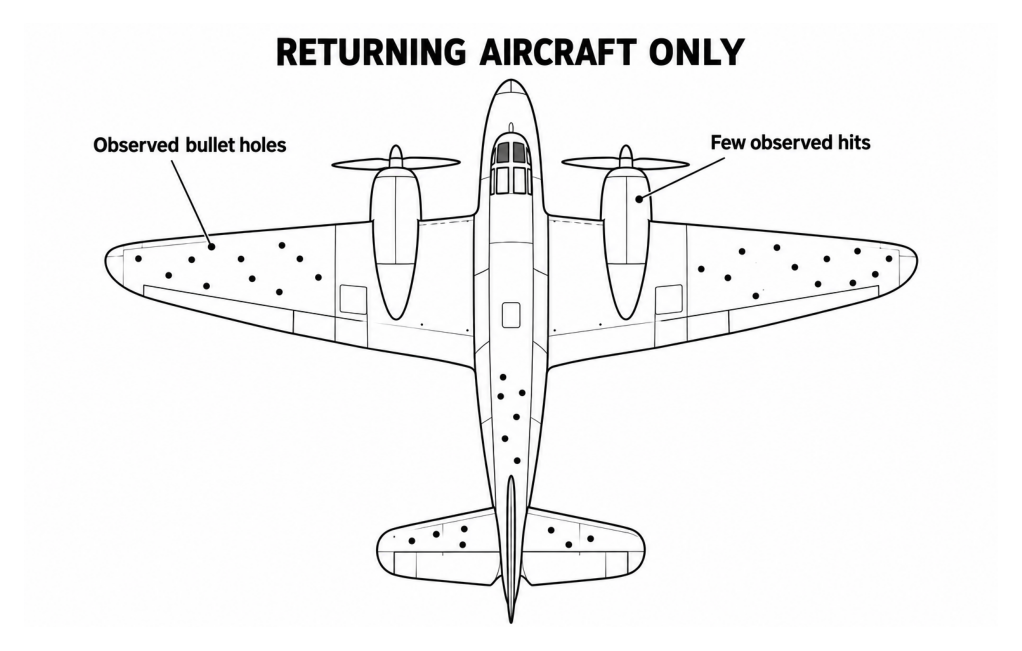

In [4]:
fig, ax = plt.subplots(figsize=(4.3, 2.9))
ax.imshow(plt.imread(project/'companion/assets/returning-aircraft-schematic.png'))
ax.set_axis_off()
save(2,3,'The sample contains only returning aircraft','Conceptual illustration, not historical damage records. Bullet holes show damage that returning aircraft survived. Sparse hits in critical areas can signal missing aircraft, not safety, when comparable exposure and damage-dependent survival are plausible. The next figure demonstrates the selection mechanism with synthetic data.','### The Planes That Didn\'t Come Back',fig=fig)

Damage category is randomized, but survival probability depends on that category.
Counting only survivors therefore gives a biased picture of damage exposure.

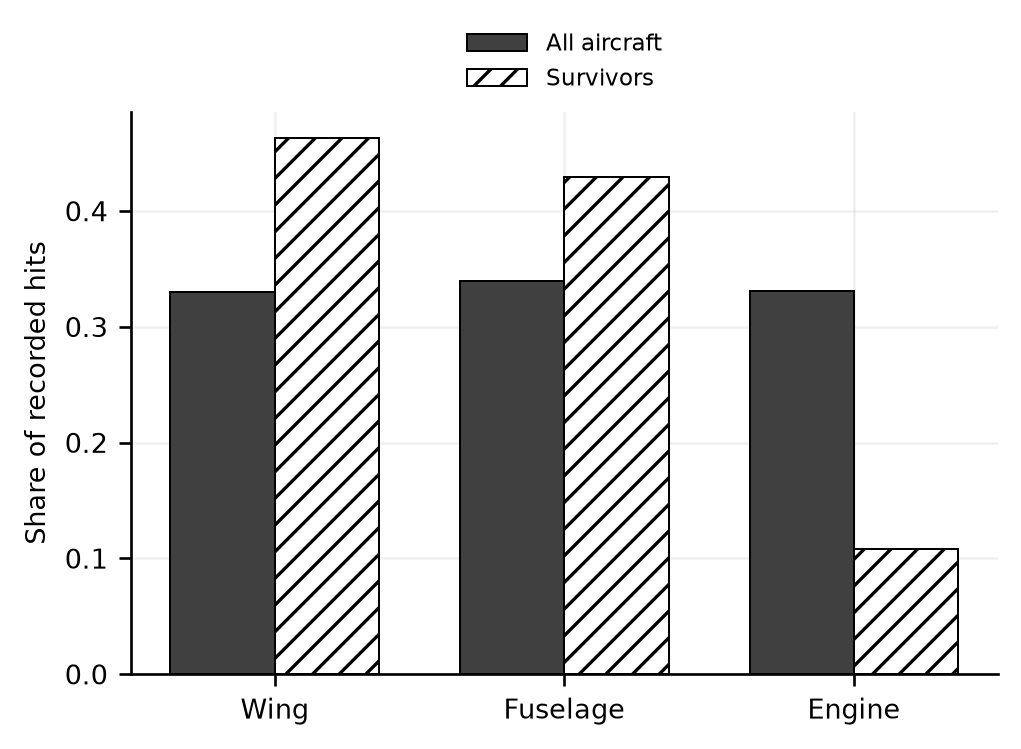

In [5]:
hit=rng.integers(0,3,10000); survival=rng.random(10000)<np.array([.9,.8,.2])[hit]
all_rates=np.bincount(hit,minlength=3)/len(hit); returned=np.bincount(hit[survival],minlength=3)/survival.sum()
plt.figure(); pos=np.arange(3); plt.bar(pos-.18,all_rates,.36,color='.25',edgecolor='black',label='All aircraft'); plt.bar(pos+.18,returned,.36,color='white',edgecolor='black',hatch='///',label='Survivors'); plt.xticks(pos,['Wing','Fuselage','Engine']); plt.ylabel('Share of recorded hits'); plt.legend()
save(2,4,'Missing aircraft change the inference','Synthetic damage and survival process, not wartime records. Rare engine damage among survivors conceals its high fatality in the simulation. Solid bars include all aircraft; hatched bars include survivors only.','### The Planes That Didn\'t Come Back')

## Keep score, then change assumptions
A probability forecast is not judged by one outcome. Repeated Brier scores
compare forecasts on the same events. Try a much stronger prior or correlated
measurement noise and rerun. Historical geometry, life tables and tank-serial
inference are background examples; the core computations here concern uncertainty.

In [6]:
p=rng.uniform(.1,.9,1000); outcomes=rng.binomial(1,p)
print('Truth probabilities Brier:',brier(p,outcomes),'constant forecast:',brier(np.repeat(.5,1000),outcomes))
assert brier([0,1],[0,1])==0

Truth probabilities Brier: 0.18985617607204808 constant forecast: 0.25


<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
CSV successes,trials with integer 0 <= successes <= trials and trials > 0; rows must represent disjoint comparable batches. Config prior_alpha and prior_beta are positive. Record population, sampling window and observation/selection rules.

Minimal **format illustration**, not sufficient training data:

```csv
successes,trials
7,10
```

## Explain the mechanism

Bayesian updating combines prior and likelihood rather than replacing uncertainty with an observed percentage. Selection bias concerns which observations enter the calculation; more selected data can make a wrong inference more precise.

## Work through the arithmetic

Beta(2,2) plus seven successes in ten trials gives Beta(9,5), with mean 9/14=.642857. The observed success rate is .7 and the prior mean .5, so the posterior is between them. The predictive success probability for one exchangeable next trial is also 9/14; a credible interval describes the latent probability, not a binary outcome.

## Adapt the lesson to reader data

Replace the successes/failures and prior inputs in the first lesson block. Keep survivor diagrams conceptual unless historical observations are actually supplied. If source data list individual cases, deduplicate them and derive disjoint success/trial counts without dropping failures.

For this chapter, settle these questions before fitting: What counts as a trial and success? Are trials independent and comparable? Why this prior? Which failures or nonrespondents are missing?

## Interpret the actual lesson outputs

The posterior density is normalized. The paired-measurement cloud shares latent ability with independent new noise. The aircraft illustration is conceptual; the subsequent controlled simulation supplies a known selection mechanism, not evidence about historical aircraft.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `prior_strength,posterior_mean,lower,upper`.
- `summary.json`: `successes,failures,posterior_alpha,posterior_beta` plus method, interpretation, assumptions, not_done and status.

The three rows use .25×, 1× and 4× prior strength, with 95% posterior credible bounds. They hold the prior mean fixed. There is no future-count interval in this output.

## Decide what the evidence supports

Posterior concentration is conditional on the prior, binomial sampling and representativeness. Regression toward the mean needs noisy repeated measurements; it is not proof that an intervention worked. Survivor-only records can reverse an inference.

If denominators are unknown, do not fit a binomial posterior. If outcomes are selected, describe selection scenarios or obtain the missing cohort. With clustered data, aggregate at a defensible independent unit or use a separately justified hierarchical model.

The applied deliverable must make these items inspectable: `results.csv` columns: `prior_strength,posterior_mean,lower,upper`; `summary.json` keys: `successes,failures,posterior_alpha,posterior_beta` plus method, interpretation, assumptions, not_done and status. Return success/trial totals, prior and posterior parameters, posterior mean and credible interval, sensitivity to the prior and a selection-process note. Label future-count predictions separately.

## Three exercises with worked solutions

### Exercise 1

Beta(1,1), three successes in four trials: posterior?

**Worked solution.** Beta(4,2), mean 4/6=2/3.

### Exercise 2

A database contains 90 successes but no count of attempts. What can be updated?

**Worked solution.** Not a binomial probability. Obtain the attempts denominator or report counts without a probability estimate.

### Exercise 3

Low performers improved on retesting after coaching. Is coaching identified?

**Worked solution.** No. Measurement noise and selection can produce regression toward the mean. A credible comparator or experiment is needed.

## Business-reader application

Use this request with the skill:

> Use chapter 2 to update the success probability from batches.csv, explain the prior in business terms, and audit whether missing failures invalidate the calculation.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [7]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch02.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch02.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(2, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch02-workshop-results.csv', index=False)
_ = (workshop_output/'ch02-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Beta-binomial posterior with prior-strength sensitivity
Status: passed

Interpretation: With 21 successes in 32 trials and a Beta(2,2) prior, the posterior mean is 0.639 (95% credible 0.478 to 0.785). The other rows vary the prior strength while keeping its mean; if they disagree materially, the data are not yet decisive.

Assumptions:
  - Trials are exchangeable Bernoulli draws with one common success probability
  - The recorded trials are all the trials (no selection of favourable results)
  - The prior expresses belief before these trials
Not done:
  - No pooling across groups or time (a hierarchical model)
  - Prior parameters were supplied, not elicited or checked against outside evidence

Evidence:
  successes: 21
  failures: 11
  posterior_alpha: 23
  posterior_beta: 13

Table: 3 rows, columns ['prior_strength', 'posterior_mean', 'lower', 'upper']

 prior_strength  posterior_mean  lower  upper
           0.25           0.652  0.484  0.802
           1.00           0.639